Creo que este es el modelo que mejor resultado me ha dado, obteniendo un score de 0.7974, en el concurso me llamo luissinho1999

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from pandas.plotting import scatter_matrix
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import accuracy_score, auc, confusion_matrix, f1_score, precision_score, recall_score, roc_curve 
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score
import pycaret
from pycaret.classification import *
import lime

In [114]:
ruta_archivo = r'C:\Users\luissinho1999\Downloads\Machine_learning.csv'

datos = pd.read_csv(ruta_archivo)

print(datos.head())

ruta_archivo_2 = r'C:\Users\luissinho1999\Downloads\Etiquetas_ML.csv'
etiquetas= pd.read_csv(ruta_archivo_2)

print(etiquetas.head()) 
# Unir los DataFrames por la columna 'id'
df_train = datos.merge(etiquetas, on='id')

df_train = df_train.set_index('id')


print(df_train.head())


      id  amount_tsh date_recorded        funder  gps_height     installer  \
0  69572      6000.0    2011-03-14         Roman        1390         Roman   
1   8776         0.0    2013-03-06       Grumeti        1399       GRUMETI   
2  34310        25.0    2013-02-25  Lottery Club         686  World vision   
3  67743         0.0    2013-01-28        Unicef         263        UNICEF   
4  19728         0.0    2011-07-13   Action In A           0       Artisan   

   longitude   latitude              wpt_name  num_private  ... payment_type  \
0  34.938093  -9.856322                  none            0  ...     annually   
1  34.698766  -2.147466              Zahanati            0  ...    never pay   
2  37.460664  -3.821329           Kwa Mahundi            0  ...   per bucket   
3  38.486161 -11.155298  Zahanati Ya Nanyumbu            0  ...    never pay   
4  31.130847  -1.825359               Shuleni            0  ...    never pay   

  water_quality quality_group      quantity  quant

In [115]:
df_train['status_group'].value_counts()
#vemos que hay mucho menos de functional needs repair respecto a las otras categorias

status_group
functional                 32259
non functional             22824
functional needs repair     4317
Name: count, dtype: int64

In [116]:
print(df_train.isnull().sum())

amount_tsh                   0
date_recorded                0
funder                    3637
gps_height                   0
installer                 3655
longitude                    0
latitude                     0
wpt_name                     2
num_private                  0
basin                        0
subvillage                 371
region                       0
region_code                  0
district_code                0
lga                          0
ward                         0
population                   0
public_meeting            3334
recorded_by                  0
scheme_management         3878
scheme_name              28810
permit                    3056
construction_year            0
extraction_type              0
extraction_type_group        0
extraction_type_class        0
management                   0
management_group             0
payment                      0
payment_type                 0
water_quality                0
quality_group                0
quantity

In [117]:
#Depuración de los datos

# Lista de columnas a eliminar
columnas_eliminar = ['num_private', 'public_meeting', 'permit', 'recorded_by', 'water_quality', 'management_group', 'source_class']
#Esto ha sido obtenido una vez visto las features y la correlación de cada variable visto posteriormente

# Eliminar las columnas del DataFrame df_train
df_train = df_train.drop(columns=columnas_eliminar)


# Inicializar listas para almacenar los nombres de las columnas según su tipo
lista_numericas = []
lista_categoricas = []
lista_binarias = []

# Iterar sobre las columnas del DataFrame df_train
for columna in df_train.columns:
    # Si la columna es de tipo numérico, agregarla a lista_numericas
    if pd.api.types.is_numeric_dtype(df_train[columna]):
        lista_numericas.append(columna)
    # Si la columna es de tipo categórico y tiene solo dos categorías únicas, agregarla a lista_binarias
    elif pd.api.types.is_categorical_dtype(df_train[columna]) or df_train[columna].dtype == 'object':
        if df_train[columna].nunique() == 2:
            lista_binarias.append(columna)
        else:
            lista_categoricas.append(columna)

# Convertir las listas en conjuntos para eliminar duplicados
lista_numericas = list(set(lista_numericas))
lista_categoricas = list(set(lista_categoricas))
lista_binarias = list(set(lista_binarias))

#Variables que se eliminaron de las columnas numéricas
variables_categoricas = ['district_code', 'region_code']
for variable in variables_categoricas:
    if variable in lista_numericas:
        lista_numericas.remove(variable)

# Agregar las variables a la lista de columnas categóricas
lista_categoricas.extend(variables_categoricas)


# Eliminar la variable 'status_group' de la lista categorica, si está presente
if 'status_group' in lista_categoricas:
    lista_categoricas.remove('status_group')

# Imprimir las listas resultantes
print("Columnas numéricas:", lista_numericas)
print("Columnas categóricas:", lista_categoricas)
print("Columnas binarias:", lista_binarias)


# Inicializamos el LabelEncoder
le = LabelEncoder()

# Iteramos sobre cada variable categórica y aplicamos la transformación, excepto la variable objetivo
for col in lista_categoricas:
    if col != 'status_group':  # Evitamos codificar la variable objetivo 'status_group'
        # Ajustamos el LabelEncoder a las categorías únicas de la columna actual
        le.fit(df_train[col])
        
        # Transformamos la columna actual y reemplazamos los valores en el DataFrame
        df_train[col] = le.transform(df_train[col])


# Iterar sobre las variables categóricas y binarias para identificar valores nulos
for col in lista_categoricas:
    if df_train[col].isnull().any():
        # Encontrar el primer valor entero que no corresponda a ninguna categoría existente
        primer_valor_entero = 1
        while primer_valor_entero in df_train[col].values:
            primer_valor_entero += 1
        # Rellenar los valores nulos con el primer valor entero encontrado
        df_train[col].fillna(primer_valor_entero, inplace=True)

df_train.head()


Columnas numéricas: ['population', 'gps_height', 'construction_year', 'longitude', 'latitude', 'amount_tsh']
Columnas categóricas: ['installer', 'quantity', 'scheme_name', 'payment_type', 'funder', 'scheme_management', 'wpt_name', 'extraction_type_class', 'date_recorded', 'lga', 'subvillage', 'basin', 'region', 'management', 'source_type', 'payment', 'extraction_type_group', 'waterpoint_type', 'ward', 'source', 'waterpoint_type_group', 'extraction_type', 'quantity_group', 'quality_group', 'district_code', 'region_code']
Columnas binarias: []


,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,basin,subvillage,...,payment,payment_type,quality_group,quantity,quantity_group,source,source_type,waterpoint_type,waterpoint_type_group,status_group
id,,,,,,,,,,,,,,,,,,,,,
69572,6000.0,47,1368,1390,1518,34.938093,-9.856322,37398,1,11807,...,2,0,2,1,1,8,6,1,1,functional
8776,0.0,309,469,1399,545,34.698766,-2.147466,37194,4,15838,...,0,2,2,2,2,5,3,1,1,functional
34310,25.0,300,825,686,2048,37.460664,-3.821329,14572,5,9074,...,4,5,2,1,1,0,1,2,1,functional
67743,0.0,272,1740,263,1852,38.486161,-11.155298,37284,7,8982,...,0,2,2,0,0,3,0,2,1,non functional
19728,0.0,104,20,0,119,31.130847,-1.825359,35528,4,7698,...,0,2,2,3,3,5,3,1,1,functional


Una vez con los datos depurados he utilizado pycaret, aunque he borrado los inputs por que solo he utilizado las conclusiones 
expuestas posteriormente así mejora la claridad de la entrega
Las conclusiones que saco de pycaret son las siguientes:
Mejor modelo: RandomForestClassifier
Predice peor functional needs repair

In [118]:
# Dividir el conjunto de datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(df_train.drop('status_group', axis=1),
                                                    df_train['status_group'],
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=df_train['status_group'])


In [119]:
#Modelo 1
model1 = RandomForestClassifier().fit(X_train,y_train)
y_pred = model1.predict(X_test)

In [120]:
def saca_metricas(y_test, y_pred):
    print("matriz de confusión")
    print(confusion_matrix(y_test, y_pred))
    print("accuracy")
    print(accuracy_score(y_test, y_pred))
    print('precision')
    print(precision_score(y_test, y_pred, average='weighted'))
    print('recall')
    print(recall_score(y_test, y_pred, average='weighted'))  


# Llama a la función saca_metricas con tus etiquetas verdaderas y predichas
saca_metricas(y_test, y_pred)



matriz de confusión
[[5760  170  522]
 [ 447  271  145]
 [ 925   65 3575]]
accuracy
0.8085858585858586
precision
0.8013657609994439
recall
0.8085858585858586


In [121]:
# Crear el mapeo
mapeo = {'functional':0,'non functional':1, 'functional needs repair' :2}

# Crear una copia de df_train
df_train_copia = df_train.copy()

# Reemplazar los valores en la columna 'status_group' utilizando el mapeo
df_train_copia['status_group'] = df_train_copia['status_group'].map(mapeo)

print(df_train_copia.head())


       amount_tsh  date_recorded  funder  gps_height  installer  longitude  \
id                                                                           
69572      6000.0             47    1368        1390       1518  34.938093   
8776          0.0            309     469        1399        545  34.698766   
34310        25.0            300     825         686       2048  37.460664   
67743         0.0            272    1740         263       1852  38.486161   
19728         0.0            104      20           0        119  31.130847   

        latitude  wpt_name  basin  subvillage  ...  payment  payment_type  \
id                                             ...                          
69572  -9.856322     37398      1       11807  ...        2             0   
8776   -2.147466     37194      4       15838  ...        0             2   
34310  -3.821329     14572      5        9074  ...        4             5   
67743 -11.155298     37284      7        8982  ...        0         

In [122]:
# Calcular la matriz de correlación
correlation_matrix = df_train_copia.corr()

# Mostrar la tabla de correlación
print("Tabla de correlación:")
print(correlation_matrix)


Tabla de correlación:
                       amount_tsh  date_recorded    funder  gps_height  \
amount_tsh               1.000000      -0.015539 -0.000294    0.076650   
date_recorded           -0.015539       1.000000 -0.024786    0.278722   
funder                  -0.000294      -0.024786  1.000000   -0.025788   
gps_height               0.076650       0.278722 -0.025788    1.000000   
installer                0.005380      -0.018432  0.626962   -0.009240   
longitude                0.022134      -0.040597 -0.031129    0.149155   
latitude                -0.052670       0.255745 -0.005116   -0.035751   
wpt_name                 0.014662      -0.124461 -0.008673    0.055667   
basin                    0.013977      -0.206706 -0.177439   -0.161768   
subvillage              -0.000345       0.059188 -0.021549    0.001172   
region                  -0.019866      -0.047995  0.154850   -0.323833   
region_code             -0.028807       0.103307  0.049159   -0.151365   
district_code   

In [123]:
print(classification_report(y_test, y_pred))

                         precision    recall  f1-score   support

             functional       0.81      0.89      0.85      6452
functional needs repair       0.54      0.31      0.40       863
         non functional       0.84      0.78      0.81      4565

               accuracy                           0.81     11880
              macro avg       0.73      0.66      0.69     11880
           weighted avg       0.80      0.81      0.80     11880



<Axes: >

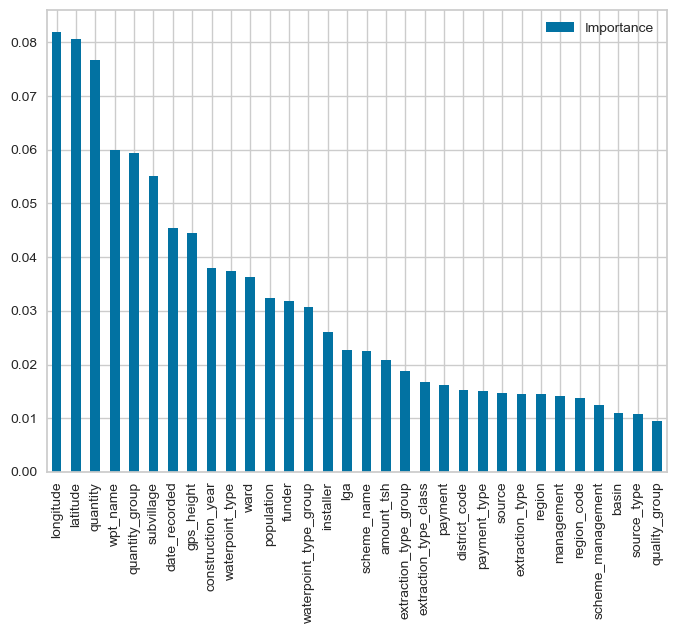

In [124]:
feat_importances = pd.DataFrame(model1.feature_importances_, index=X_train.columns, columns=["Importance"])
feat_importances.sort_values(by='Importance', ascending=False, inplace=True)
feat_importances.plot(kind='bar', figsize=(8,6))

In [125]:
# Imprime todas las importancias de las características
# Configura pandas para mostrar todas las filas
pd.set_option('display.max_rows', None)

# Ahora, cuando imprimas o muestres la Serie, verás todas las filas
print(feat_importances)



# Cuenta cuántos valores no nulos hay en cada característica
num_not_null = feat_importances.notnull().sum()

# Imprime el resultado
print("Número de valores no nulos en cada característica:")
print(num_not_null)


                       Importance
longitude                0.081938
latitude                 0.080549
quantity                 0.076721
wpt_name                 0.060034
quantity_group           0.059434
subvillage               0.055121
date_recorded            0.045494
gps_height               0.044550
construction_year        0.037949
waterpoint_type          0.037427
ward                     0.036289
population               0.032322
funder                   0.031870
waterpoint_type_group    0.030752
installer                0.026023
lga                      0.022756
scheme_name              0.022586
amount_tsh               0.020869
extraction_type_group    0.018795
extraction_type_class    0.016775
payment                  0.016235
district_code            0.015192
payment_type             0.015147
source                   0.014659
extraction_type          0.014499
region                   0.014490
management               0.014073
region_code              0.013826
scheme_managem

Estos datos de arriba, las features y la tabla de correlación, me han servido para depurar el modelo

In [126]:
#Modelo 2, Haciendo sobremuestreo de functional needs repair

#Subimos a 5000 functional needs repair mediante over sampling
sampling_strategy = {'functional needs repair': 5000}

# Aplicar SMOTE con la proporción de sobremuestreo especificada
smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Modelo 2
model2 = RandomForestClassifier().fit(X_train_resampled,y_train_resampled)
y_pred = model2.predict(X_test)


saca_metricas(y_test, y_pred)



matriz de confusión
[[5743  176  533]
 [ 442  283  138]
 [ 931   65 3569]]
accuracy
0.8076599326599326
precision
0.8009906473261276
recall
0.8076599326599326


In [127]:
# Cargamos los nuevos datos desde el archivo CSV
nuevos_datos = pd.read_csv(r'C:\Users\luissinho1999\Downloads\Test_ML.csv')

nuevos_datos.head()



,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,50785,0.0,2013-02-04,Dmdd,1996,DMDD,35.290799,-4.059696,Dinamu Secondary School,0,...,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,other,other
1,51630,0.0,2013-02-04,Government Of Tanzania,1569,DWE,36.656709,-3.309214,Kimnyak,0,...,never pay,soft,good,insufficient,insufficient,spring,spring,groundwater,communal standpipe,communal standpipe
2,17168,0.0,2013-02-01,NaN,1567,NaN,34.767863,-5.004344,Puma Secondary,0,...,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,other,other
3,45559,0.0,2013-01-22,Finn Water,267,FINN WATER,38.058046,-9.418672,Kwa Mzee Pange,0,...,unknown,soft,good,dry,dry,shallow well,shallow well,groundwater,other,other
4,49871,500.0,2013-03-27,Bruder,1260,BRUDER,35.006123,-10.950412,Kwa Mzee Turuka,0,...,monthly,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe


In [128]:
nulos_por_columna = nuevos_datos.isnull().sum()
print("Número de valores nulos en cada columna de datos_nuevos:")
print(nulos_por_columna)



Número de valores nulos en cada columna de datos_nuevos:
id                          0
amount_tsh                  0
date_recorded               0
funder                    870
gps_height                  0
installer                 877
longitude                   0
latitude                    0
wpt_name                    0
num_private                 0
basin                       0
subvillage                 99
region                      0
region_code                 0
district_code               0
lga                         0
ward                        0
population                  0
public_meeting            821
recorded_by                 0
scheme_management         969
scheme_name              7242
permit                    737
construction_year           0
extraction_type             0
extraction_type_group       0
extraction_type_class       0
management                  0
management_group            0
payment                     0
payment_type                0
water_quality

In [129]:
# Eliminar las columnas depuradas del DataFrame nuevos_datos
nuevos_datos = nuevos_datos.drop(columns=columnas_eliminar)

# Iterar sobre las variables categóricas y binarias para identificar valores nulos
for col in lista_categoricas + lista_binarias:
    if nuevos_datos[col].isnull().any():
        # Encontrar el primer valor entero que no corresponda a ninguna categoría existente
        primer_valor_entero = 1
        while primer_valor_entero in nuevos_datos[col].values:
            primer_valor_entero += 1
        # Rellenar los valores nulos con el primer valor entero encontrado
        nuevos_datos[col].fillna(primer_valor_entero, inplace=True)

# Eliminar la columna 'id' de nuevos_datos
nuevos_datos = nuevos_datos.set_index('id')

        

In [130]:
lista_numericas = []
lista_categoricas = []
lista_binarias = []

# Iterar sobre las columnas del DataFrame nuevos_datos
for columna in nuevos_datos.columns:
    # Si la columna es de tipo numérico, agregarla a lista_numericas
    if pd.api.types.is_numeric_dtype(nuevos_datos[columna]):
        lista_numericas.append(columna)
    # Si la columna es de tipo categórico y tiene solo dos categorías únicas, agregarla a lista_binarias
    elif pd.api.types.is_categorical_dtype(nuevos_datos[columna]) or nuevos_datos[columna].dtype == 'object':
        if nuevos_datos[columna].nunique() == 2:
            lista_binarias.append(columna)
        else:
            lista_categoricas.append(columna)

# Convertir las listas en conjuntos para eliminar duplicados
lista_numericas = list(set(lista_numericas))
lista_categoricas = list(set(lista_categoricas))
lista_binarias = list(set(lista_binarias))

# Eliminar la variable 'y' de la lista categorica, si está presente
if 'status_group' in lista_categoricas:
    lista_categoricas.remove('status_group')

# Imprimir las listas resultantes
print("Columnas numéricas:", lista_numericas)
print("Columnas categóricas:", lista_categoricas)
print("Columnas binarias:", lista_binarias)


Columnas numéricas: ['population', 'gps_height', 'construction_year', 'longitude', 'latitude', 'district_code', 'amount_tsh', 'region_code']
Columnas categóricas: ['installer', 'quantity', 'scheme_name', 'payment_type', 'funder', 'scheme_management', 'wpt_name', 'extraction_type_class', 'date_recorded', 'lga', 'subvillage', 'basin', 'region', 'management', 'source_type', 'payment', 'extraction_type_group', 'waterpoint_type', 'ward', 'source', 'waterpoint_type_group', 'extraction_type', 'quantity_group', 'quality_group']
Columnas binarias: []


In [131]:
print(nuevos_datos.isnull().sum())

amount_tsh               0
date_recorded            0
funder                   0
gps_height               0
installer                0
longitude                0
latitude                 0
wpt_name                 0
basin                    0
subvillage               0
region                   0
region_code              0
district_code            0
lga                      0
ward                     0
population               0
scheme_management        0
scheme_name              0
construction_year        0
extraction_type          0
extraction_type_group    0
extraction_type_class    0
management               0
payment                  0
payment_type             0
quality_group            0
quantity                 0
quantity_group           0
source                   0
source_type              0
waterpoint_type          0
waterpoint_type_group    0
dtype: int64


In [132]:
# Convertir todas las columnas categóricas a tipo de datos de cadena
nuevos_datos[lista_categoricas] = nuevos_datos[lista_categoricas].astype(str)

# Inicializar el LabelEncoder
le = LabelEncoder()

# Iterar sobre cada variable categórica y aplicar la transformación
for col in lista_categoricas:
    if col != 'status_group':  # Evitar codificar la variable objetivo 'status_group'
        # Ajustar el LabelEncoder a las categorías únicas de la columna actual
        le.fit(nuevos_datos[col])
        
        # Transformar la columna actual y reemplazar los valores en el DataFrame
        nuevos_datos[col] = le.transform(nuevos_datos[col])

nuevos_datos.head()

,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,basin,subvillage,...,management,payment,payment_type,quality_group,quantity,quantity_group,source,source_type,waterpoint_type,waterpoint_type_group
id,,,,,,,,,,,,,,,,,,,,,
50785,0.0,255,176,1996,215,35.290799,-4.059696,656,0,3916,...,3,0,2,2,3,3,5,3,6,5
51630,0.0,255,251,1569,222,36.656709,-3.309214,1780,5,2717,...,7,0,2,2,2,2,8,6,1,1
17168,0.0,252,1,1567,1,34.767863,-5.004344,9673,0,5398,...,7,0,2,2,2,2,5,3,6,5
45559,0.0,242,223,267,263,38.058046,-9.418672,5595,7,2795,...,7,6,6,2,0,0,7,5,6,5
49871,500.0,306,74,1260,76,35.006123,-10.950412,5706,7,3544,...,9,3,1,2,1,1,8,6,1,1


In [133]:
# Obtener las columnas comunes entre df_train y nuevos_datos
columnas_comunes = df_train.columns.intersection(nuevos_datos.columns)

# Reordenar las columnas de nuevos_datos para que coincidan con el orden de df_train
nuevos_datos = nuevos_datos[columnas_comunes]

# Añadir la nueva columna al final del DataFrame nuevos_datos
nuevos_datos['extraction_type_other - mkulima/shinyanga'] = 0



In [134]:
# Obtener las columnas presentes en df_train pero no en nuevos_datos
columnas_perdidas_entrenamiento = set(df_train.columns) - set(nuevos_datos.columns)

# Obtener las columnas presentes en nuevos_datos pero no en df_train
columnas_nuevas = set(nuevos_datos.columns) - set(df_train.columns)

print("Características que tenías durante el entrenamiento pero que ya no tienes en los nuevos datos:")
print(columnas_perdidas_entrenamiento)

print("\nCaracterísticas que tienes ahora en los nuevos datos pero que no tenías durante el entrenamiento:")
print(columnas_nuevas)


Características que tenías durante el entrenamiento pero que ya no tienes en los nuevos datos:
{'status_group'}

Características que tienes ahora en los nuevos datos pero que no tenías durante el entrenamiento:
{'extraction_type_other - mkulima/shinyanga'}


In [135]:
# Obtener las columnas comunes entre df_train y nuevos_datos
columnas_comunes = df_train.columns.intersection(nuevos_datos.columns)

# Reordenar las columnas de nuevos_datos para que coincidan con el orden de df_train
nuevos_datos = nuevos_datos[columnas_comunes]

# Añadir las columnas faltantes con valores 0 si es necesario
columnas_faltantes = df_train.columns.difference(nuevos_datos.columns)
for columna in columnas_faltantes:
    nuevos_datos[columna] = 0



In [136]:
#Quitamos status group como variable explicativa
columnas_ordenadas = [col for col in df_train.columns.tolist() if col != 'status_group']

# Reordenamos las columnas de 'X_nuevos' para que coincidan con el orden de 'df_train'
X_nuevos = nuevos_datos[columnas_ordenadas]

y_pred_nuevos = model2.predict(X_nuevos)


# Evaluar el rendimiento del modelo con los nuevos datos

y_verdaderos = nuevos_datos['status_group']  
  # Ajusta el nombre de la variable objetivo

mapeo = {0: 'functional', 1: 'non functional', 2: 'functional needs repair'}

# Usa el método replace para cambiar los valores
y_verdaderos = y_verdaderos.replace(mapeo)

accuracy_nuevos = accuracy_score(y_verdaderos, y_pred_nuevos)
print("Exactitud en los nuevos datos:", accuracy_nuevos)

# Muestra los primeros 5 ejemplos
print(y_verdaderos.head())
print(y_pred_nuevos)


Exactitud en los nuevos datos: 0.6293602693602693
id
50785    functional
51630    functional
17168    functional
45559    functional
49871    functional
Name: status_group, dtype: object
['non functional' 'functional' 'non functional' ... 'functional'
 'functional' 'non functional']


In [137]:
ruta_archivo = (r'C:\Users\luissinho1999\Desktop\UCM\Machine Learning/predicciones3.csv')

# Crear un DataFrame con 'id' como índice y 'y_pred_nuevos' como columna
df_predicciones = pd.DataFrame(y_pred_nuevos, index=nuevos_datos.index, columns=['status_group'])

df_predicciones.to_csv(ruta_archivo)

print(f"Las predicciones se han guardado en '{ruta_archivo}'")



Las predicciones se han guardado en 'C:\Users\luissinho1999\Desktop\UCM\Machine Learning/predicciones3.csv'
